In [1]:
#The whole cell ran successfully

#we can input this all into forRealSVM_starting once I've created the csv file

# imports the json module, which handles json files
import json

#tries to open my json file
try:
    with open('acndata_sessions (7).json') as f:

        #uses .load to parse the file's contents into a list or dictionary. If the json file is valid, it gets stored in "data"
        data = json.load(f)

        # if  the file is invalid or corrupted, it catches the JSONDecodeError
        #e is an exception object that gets created when the error occurrs. it contains details about where and why the json parsing failed
except json.JSONDecodeError as e:
    #prints detailed error feedback if the file is malformed(figure out what they mean by malformed) 
    #(I don't think it's malformed cuz this prints nothing)
    print(f"Error decoding JSON: {e}") 
    #the line number, column, and character position where the problem occurred
    #this is something called an "f-string", in which curly brackets let you embed a variable directly into a string. e.lineno is the...
    #...exact line in the original JSON file where the error occurred
    print(f"Error at line {e.lineno}, column {e.colno}, character {e.pos}") 


In [2]:
import pandas as pd

# Load the JSON file
# the lack of a "try" statement here makes it assume there are no errors, so we can't do the error handling here that we did in the previous block
with open('acndata_sessions (7).json', 'r') as file:
    data = json.load(file)

# Initialize a list to store the EV charging session data
sessions_list = []





# Loop through the items and extract relevant fields
# here, 'items' is not something I created but a LIST that already exists in my natural json file(go to the Jupyter json file and I will see..
# ...it inside "root", alongside "meta"
for session in data['_items']:
    # Extract general session data: this turns every charging session(every list) inside 'items' in "data" into a dictionary(a single, full row)
    session_data = {   # filling the session_data list and TURNING IT INTO A DICTIONARY
        "_id": session.get("_id"),
        "clusterID": session.get("clusterID"), #ID of a specific group of EV supply equipment, like the ID of a single garage
        "connectionTime": session.get("connectionTime"), # RTF 1123 format
        "disconnectTime": session.get("disconnectTime"),
        "doneChargingTime": session.get("doneChargingTime"),
        "kWhDelivered": session.get("kWhDelivered"),
        "sessionID": session.get("sessionID"),
        "siteID": session.get("siteID"),
        "spaceID": session.get("spaceID"), #ID of the parking space
        "stationID": session.get("stationID"),
        "timezone": session.get("timezone"),
        "userID": session.get("userID") #only exists if the charging session is claimed using the mobile app
    }

    # Extract user inputs if available(this is INSIDE the larger for loop!)
    if session.get("userInputs"): #this is checking if, for each charging session that the for loop loops through, the user inputted anything
        user_inputs = session["userInputs"][0]  # Assuming the first user input if multiple
        session_data.update({
            #adds more fields to the dictionary because there are more fields in this case
            "WhPerMile": user_inputs.get("WhPerMile"),
            "kWhRequested": user_inputs.get("kWhRequested"),
            "milesRequested": user_inputs.get("milesRequested"),
            "minutesAvailable": user_inputs.get("minutesAvailable"),
            "modifiedAt": user_inputs.get("modifiedAt"),
            "paymentRequired": user_inputs.get("paymentRequired"),
            "requestedDeparture": user_inputs.get("requestedDeparture"),
            "userInput_userID": user_inputs.get("userID")
        })

          
    # Append session data to the list
    sessions_list.append(session_data) #we do this a bunch of times since we're looping, which gives us a full list of charging sessions


#WE HAVE NOW EXITED THE FOR LOOP
# Convert sessions_list(which is now a dictionary) to a pandas DataFrame
df_sessions = pd.DataFrame(sessions_list)
# Convert df_sessions(the dataframe of my sessions_list that I made) into a CSV FILE
df_sessions.to_csv('session_data.csv', index=False) #index=False just means it won't include the row index as its own column in the file

In [1]:
import pandas as pd
df = pd.read_csv('newest_data.csv')
print(df.head())

   connection_minute  connection_hour  connection_day_of_month  \
0                 17                6                       25   
1                  0                7                       25   
2                 43                7                       25   
3                 26                8                       25   
4                 12                9                       25   

   connection_month  done_minute  done_hour  done_day_of_month  done_month  \
0                 4           40          6                 25           4   
1                 4           23          7                 25           4   
2                 4           17          8                 25           4   
3                 4           55          8                 25           4   
4                 4           28          9                 25           4   

   spaceID  duration  kWhDelivered  is_attack  multiclass  
0      148      23.0     14.831715          1           3  
1      148    

In [2]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from datetime import timedelta

# Load the dataset
df = pd.read_csv('session_data.csv')

# Convert connectionTime and doneChargingTime(features/columns of df) to datetime
df['connectionTime'] = pd.to_datetime(df['connectionTime'])
# datetime Format: YYYY-MM(as a number)-DD(day of the month) HH:MM:SS
df['doneChargingTime'] = pd.to_datetime(df['doneChargingTime'])

# df.head WORKS! IT PRINTS CONNECTION TIME AND DONE CHARGING TIME AS WHAT I CONVERTED IT TO!
# print(df.head())


# Parameters
attack_percentage = 0.20  # 10% of stations will be attacked per day(I have no idea wtf is going on here)
# .unique() returns an array of all the distinct values found in an array.
stations = df['spaceID'].unique() #the variable "station" is a list of the unique rows in the spaceID column(unique parking space has its own charging station)
days = df['connectionTime'].dt.date.unique()  # the variable "days" is a list of the unique dates in the connectionTime column

# Define attack ranges
connection_time_increase_range = 15  # 15 minutes
done_charging_time_decrease_range = 15  # 15 minutes
demand_change_factor = 0.4  # 40% increase(ask if demand change factor is miles requested and Kwh requested).

# Initialize columns
df['is_attack'] = 0 # creates a NEW COLUMN called 'is_attack' that equals 0 if it's a cyberattack. Fills this column with zeroes.
df['changed_connectionTime'] = df['connectionTime'] #this makes all the connectionTimes be copied into a new column called changed_connectionTime
df['changed_doneChargingTime'] = df['doneChargingTime'] #this copies all the doneChargingTimes into a new column called changed_doneChargingTime
df['changed_kWhDelivered'] = df['kWhDelivered'] #this copies all the kwHDelivered into a new column called changed_kWhdelivered
df['multiclass'] = 0  # Default class 0 for no attack. class 1 will equal attack, and I'm not sure what the other classes will be, but there will...
#...be more because I will be putting this into a multiclass support vector classifier

# Intelligent attack function with multiclass logic
# This function makes it so that if the value in changed_connectionTime doesn't equal the value in connectionTime, then that row has 
#...had a changedConnectionTime
def intelligent_attack(row, attack_types):
    if 'increase_start' in attack_types: 
        increment = timedelta(minutes=connection_time_increase_range) #increments the timedelta by 15 minutes (using the timedelta function)
        row['changed_connectionTime'] = row['connectionTime'] + increment #changes a value in the changed_connectionTime to a value that is 15 min...
        #...higher than a normal connection time
    if 'decrease_done' in attack_types: #if charging time ends earlier than normal
        decrement = timedelta(minutes=done_charging_time_decrease_range) #decrements the timedelta by 15 minutes
        #there is a timedelta function somewhere
        row['changed_doneChargingTime'] = row['doneChargingTime'] - decrement #changes a value in the changed_doneChargingTime column to...
        #...something that is one decrement lesser than the original doneChargingTime
    if 'change_demand' in attack_types: #increases the demand by 40% if a change in demand s found in the list called attack_types
        demand_change = row['kWhDelivered'] * demand_change_factor #creates a value that is a single kwhDelivered entry times the demand change ...
        #...factor of 0.4
        row['changed_kWhDelivered'] = row['kWhDelivered'] + demand_change #in changed_kWhDelivered column of the inputted row, the value in that...
        #...column will become the KwhDelivered column of row plus 40% of itself.
     # Set the appropriate class based on the types of attacks applied
    if attack_types == ['increase_start']:
        row['multiclass'] = 1 #class 1 means a cyberattack identified by an increase_start time
    elif attack_types == ['decrease_done']:
        row['multiclass'] = 2 # class 2 means a cyberattack identified by the doneChargingTime decreasing
    elif attack_types == ['change_demand']:
        row['multiclass'] = 3 # class 3 means a cyberattack identified by the demand of energy and mileage increasing by 40%
    elif attack_types == ['increase_start', 'change_demand']:
        row['multiclass'] = 4 # class 4 means a cyberattack identified by both an increase in start time and an increase in demand.
    elif attack_types == ['increase_start', 'change_demand', 'decrease_done']:
        row['multiclass'] = 5 # class 5 means a cyberattack identified by an increase in start time, an increase in demand, and a decrease in done time

    row['is_attack'] = 1
    return row
# End of the function






# Apply attacks per day(makes the variable attacked_stations=how MANY stations were attacked per unique day)
for day in days:
    day_df = df[df['connectionTime'].dt.date == day] # creates a new dataframe that is a list of all entries in the "connectionTime" column of df... 
    #...where the entries in that column have a unique date.
    daily_stations = day_df['spaceID'].unique() # daily stations is a list of the unique parking spaces that ALSO have a unique day
    #max() returns the maximum of the numbers you insert, so if the attack perc. times the number of daily stations is less than one, it will at least
    #...return 1. Otherwise, it will return the exact whole number of daily stations that were attacked.
    num_attacked = max(1, int(attack_percentage * len(daily_stations))) # num_attacked is the maximum between 1 and the number of "daily_stations"...
    #...that exist.
    # random is a module. 
    attacked_stations = random.sample(list(daily_stations), num_attacked) # randomly selects a specified number(num_attacked)...
    #...of unique elements from a list. It doesn't select the attacked stations, it selects the NUMBER of stations that were attacked, which thus 
    #...shows us how MANY stations were attacked per unique day. atacked_stations includes stations that were not attacked.

        #Space ID = station in this situation because attacked_stations is a list of STATIONS, not charging sessions
    for station in attacked_stations:
        # station_rows = entries in the SpaceID column that equal the "attacked_station"/spaceID we are currently looping
        #through AND whose connection day equals
        #...the day that the bigger loop is looping through
        station_rows = df[(df['spaceID'] == station) & (df['connectionTime'].dt.date == day)] #specific row in the larger dataframe where we have an
        #...attacked station space and attacked station day, but not necessarily attacked
        for index, row in station_rows.iterrows(): #applies itself to ALL the chosen rows of df(now called station rows) one at a time
            attack_combination = random.choice([ #selects a random element from each list of entries of each type of attack
                ['increase_start'],
                ['decrease_done'],
                ['change_demand'],
                ['increase_start', 'change_demand'],
                ['increase_start', 'change_demand', 'decrease_done']
            ])
            df.loc[index] = intelligent_attack(row, attack_combination) #each index of each row in df that matches a day and time of an attack
            #now gets the intelligent attack function applied to it. which type of attack the attack function applies depends on which combination
            #of attacks this loop iteration finds in attack_combination


#End of triple nested for loop

# Save the modified dataset
df.to_csv('session_data_project_with_multiclass_attack_15_15_40.csv', index=False)

In [5]:
import numpy as np #helps with doing math

!pip install scikit-learn

import sklearn

import pandas as pd # allows us to read the csv file

from sklearn.svm import SVC #getting the support vector classifier from skitlearn

data = pd.read_csv('session_data_project_with_multiclass_attack_15_15_40.csv')

# Convert connectionTime and doneChargingTime columns to datetime format
df['connectionTime'] = pd.to_datetime(df['connectionTime'])
df['doneChargingTime'] = pd.to_datetime(df['doneChargingTime'])

# Suggestion 1: Calculate Duration
# Calculate the duration in minutes between connectionTime and doneChargingTime
df['duration'] = (df['doneChargingTime'] - df['connectionTime']).dt.total_seconds() / 60  # Duration in minutes

# Suggestion 2: Extract Temporal Features for both connectionTime and doneChargingTime, including minutes
# Temporal features for connectionTime

#changed connection minute to a continuous stream of minutes
df['connection_minute'] = (df['connectionTime'] - df['connectionTime'].min()).dt.total_seconds() / 60


df['connection_hour'] = df['connectionTime'].dt.hour
df['connection_day_of_month'] = df['connectionTime'].dt.day  # Day of the month
df['connection_month'] = df['connectionTime'].dt.month #creating new columns for each part of the bigger time column

# Temporal features for doneChargingTime
df['done_minute'] = df['doneChargingTime'].dt.minute
df['done_hour'] = df['doneChargingTime'].dt.hour
df['done_day_of_month'] = df['doneChargingTime'].dt.day  # Day of the month
df['done_month'] = df['doneChargingTime'].dt.month

# Clean the spaceID column to extract only numeric values
df['spaceID'] = df['spaceID'].str.extract(r'(\d+)', expand=False).astype(int)

# Select only the specified columns
final_columns = [
    'connection_minute', 'connection_hour', 'connection_day_of_month', 'connection_month',
    'done_minute', 'done_hour', 'done_day_of_month', 'done_month', 'spaceID', 'duration', 'kWhDelivered', 'is_attack', 'multiclass'
]
df = df[final_columns] # THIS LINE IS WHAT DROPS THE COLUMNS FROM THE ACN WEBSITE THAT WE DON"T WANT(hence we only have 13 columns)

# Remove rows with any NaN values
df = df.dropna()

# Display the resulting DataFrame with selected features
print(df.head(10))

# Save the modified DataFrame to a new CSV file
df.to_csv('attack_dataset_working_test.csv', index=False)

data = pd.read_csv('attack_dataset_working_test.csv')

print(data.head(20))
#connection minute: the minute when the EV plugged in(I think)
#connection hour: the hour when the EV plugged in(military time?)
#connection day of month: day of the month when the EV plugged in(I think)
#connection month: month when the EV plugged in(I think)
#done_minute: minute when the last non-zero current draw was recorded
#done hour: hour when the last non-zero current draw was recorded
# done day of month: day of the month when the last non-zero current draw was recorded(I think)
# done month: month when the last non-zero current draw was recorded(I think)
# S


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
   connection_minute  connection_hour  connection_day_of_month  \
0           0.000000               14                       26   
1          32.100000               15                       26   
2          39.816667               15                       26   
3          45.500000               15                       26   
4          64.083333               15                       26   
5          65.716667               15                       26   
6          67.650000               15                       26   
7          69.333333               15                       26   
8          71.383333               15                       26   
9          72.350000               15                       26   

   connection_month  done_minute  done_hour  done_day_of_month  done_month  \
0                 9          7.0       21.0               26.0         9.0   
1       

In [2]:
data = df

num_columns = len(data.columns) # same nmber of columns, but way more rows(23,000)
num_rows = len(data)
#This cell shows us that there are 14193 charging sessions(samples) and 13 features of charging sessions in the dataset
print("There are: ", num_rows,  "rows. There are: ", num_columns, "columns.") #remember to use commas, not pluses
print(data.head())

There are:  233280 rows. There are:  13 columns.
   connection_minute  connection_hour  connection_day_of_month  \
0                 17                6                       25   
1                  0                7                       25   
2                 43                7                       25   
3                 26                8                       25   
4                 12                9                       25   

   connection_month  done_minute  done_hour  done_day_of_month  done_month  \
0                 4           40          6                 25           4   
1                 4           23          7                 25           4   
2                 4           17          8                 25           4   
3                 4           55          8                 25           4   
4                 4           28          9                 25           4   

   spaceID  duration  kWhDelivered  is_attack  multiclass  
0      148      23.0     

In [3]:
# Compute total minutes since start
data['connection_minute'] = (
    data['connection_month'] * 30 * 24 * 60 +   # rough approximation: 30 days/month
    data['connection_day_of_month'] * 24 * 60 +
    data['connection_hour'] * 60 +
    data['connection_minute']
)

print(data.head())

   connection_minute  connection_hour  connection_day_of_month  \
0             209177                6                       25   
1             209220                7                       25   
2             209263                7                       25   
3             209306                8                       25   
4             209352                9                       25   

   connection_month  done_minute  done_hour  done_day_of_month  done_month  \
0                 4           40          6                 25           4   
1                 4           23          7                 25           4   
2                 4           17          8                 25           4   
3                 4           55          8                 25           4   
4                 4           28          9                 25           4   

   spaceID  duration  kWhDelivered  is_attack  multiclass  
0      148      23.0     14.831715          1           3  
1      148    

In [4]:
# 12 features
#We have our general X and Y now; next step: fit the support vector machine, specifically the support vector classifier, on X and Y

from sklearn.model_selection import train_test_split
# : before the comma means all rows, : after the comma means all columns
X = data.iloc[:,:12] # all the rows(n samples = 6384) and the first 12 columns(I'm sure this is correct)
     #data.iloc accesses the actual rows and columns of a dataset
#nSamples is all the rows, nFeatures is all the columns!

#ravel turns this into a 1d array that we can use for the classifier
Y = data.iloc[:,-1] #all the rows again, but only the second to last column(specifies if it's an attack) 
#the lack of a colon makes sure it only includes the last column; putting a colon there would make it access all columns except the last

import torch
from torch.utils.data import Dataset, DataLoader, random_split


#split into train 70%, val 15%, test 15%
X_train_size = int(0.7 * len(X))
Y_train_size = int(0.7 * len(Y))
X_val_size = int(0.15 * len(X))
Y_val_size = int(0.15 * len(Y))
X_test_size = len(X) - X_train_size - X_val_size
Y_test_size = len(Y) - Y_train_size - Y_val_size

X_train, X_val, X_test = random_split(
    X, 
    [X_train_size, X_val_size, X_test_size]
)

Y_train, Y_val, Y_test = random_split(
    Y, 
    [Y_train_size, Y_val_size, Y_test_size]
)


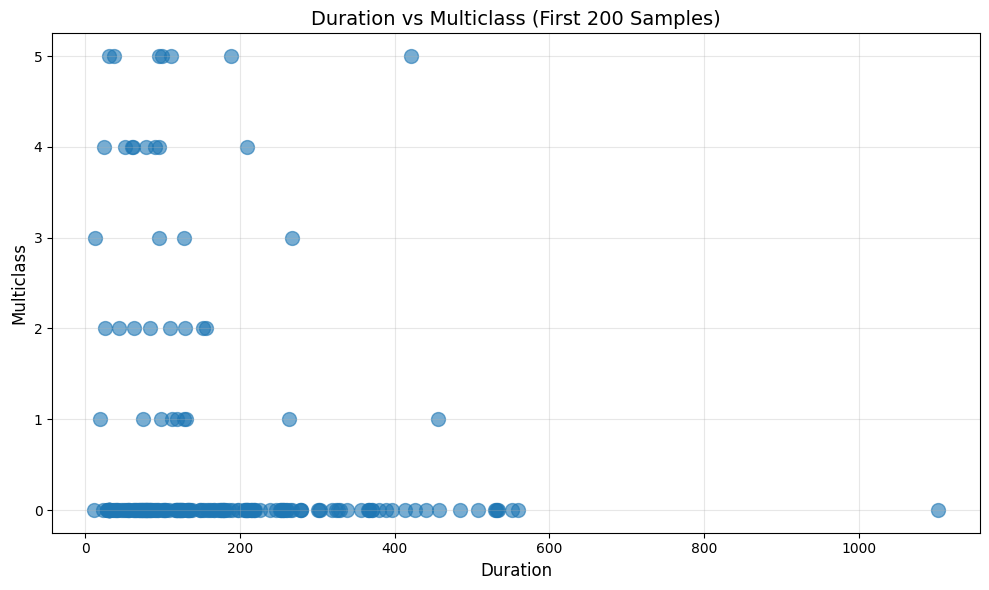

In [23]:
#visualizing the data for connection_hour
import matplotlib.pyplot as plt

# Assuming your dataframe is called 'df'
# Get first 20 samples
data_subset = data.head(200)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(data_subset['duration'], data_subset['multiclass'], 
            alpha=0.6, s=100)

plt.xlabel('Duration', fontsize=12)
plt.ylabel('Multiclass', fontsize=12)
plt.title('Duration vs Multiclass (First 200 Samples)', fontsize=14)
plt.grid(True, alpha=0.3)

# Optional: Set y-axis to show integer values only
plt.yticks(data_subset['multiclass'].unique())

plt.tight_layout()
plt.show()

In [5]:
!pip install tensorflow


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [6]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_original = X_train
X_val_original = X_val
X_test_original = X_test

groups = [group for _, group in X_train.groupby('connection_minute')]
X_train_sequences = [g.values for g in groups]
groups = [group for _, group in X_test.groupby('connection_minute')]
X_test_sequences = [g.values for g in groups]
groups = [group for _, group in X_val.groupby('connection_minute')]
X_val_sequences = [g.values for g in groups]

X_train = pad_sequences(X_train_sequences, padding='post', dtype='float32')
X_test = pad_sequences(X_test_sequences, padding = 'post', dtype ='float32')
X_val = pad_sequences(X_val_sequences, padding = 'post', dtype = 'float32')




y_groups = [group for _, group in Y_train.groupby(X_train_original['connection_minute'])]
Y_train = np.array([group.mode()[0] for group in y_groups]) # will return the most common multiclass prediction for each day
y_groups = [group for _, group in Y_test.groupby(X_test_original['connection_minute'])]
Y_test = np.array([group.mode()[0] for group in y_groups])
y_groups = [group for _, group in Y_val.groupby(X_val_original['connection_minute'])]
Y_val = np.array([group.mode()[0] for group in y_groups])



# Step 2. Convert each group to numpy arrays


import torch
from torch.utils.data import Dataset, DataLoader


X_train, X_test, Y_train, Y_test = train_test_split(X_padded, Y_train, test_size=0.2, random_state=42) #X_train and Y_train are data frames here

#oversampling minority classes

def oversample_sequences(X, y):
    from collections import Counter
    import numpy as np

    counts = Counter(y)
    max_count = max(counts.values())

    X_new = []
    y_new = []

    for label in counts:
        idx = np.where(y == label)[0]
        X_class = X[idx]
        y_class = y[idx]

        repeats = max_count // len(idx)
        remainder = max_count % len(idx)

        X_new.append(np.repeat(X_class, repeats, axis=0))
        y_new.append(np.repeat(y_class, repeats, axis=0))

        if remainder > 0:
            X_new.append(X_class[:remainder])
            y_new.append(y_class[:remainder])

    return np.concatenate(X_new), np.concatenate(y_new)




X_train, Y_train = oversample_sequences(X_train, Y_train)


print(X_train.shape)
print(X_train[0].shape)

2025-11-20 11:49:22.559236: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


(342954, 8, 12)
(8, 12)


In [8]:


import torch
from torch.utils.data import Dataset, DataLoader, random_split



# Split into train (70%), validation (15%), test (15%)
X_train_size = int(0.7 * len(X_padded))
Y_train_size = int(0.7 * len(Y_train))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    X_padded, 
    [train_size, val_size, test_size]
)


In [10]:
#training ran successfully! However, val_acuracy of 100 seems inaccurate

from sklearn.metrics import accuracy_score

from sklearn.metrics import confusion_matrix
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense

# creating the RNN model
model = Sequential()

#first layer of the neural network
#LSTM needs an activation function because it is a TYPE of recurrent neural network layer
model.add(LSTM(128, input_shape = (X_train.shape[1:]), activation = 'relu', return_sequences=True)) # adding lSTM layer with 128 memory cells

#second layer of the neural network
model.add(Dropout(0.2)) # helps prevent overfitting: 20% of neurons are randomly deactivated in each training batch

#third layer of the neural network
model.add(LSTM(128, activation = 'relu')) #default return_sequences is false, so this layer does not output timesteps. 128 memory cells

#fourth layer of the neural network
model.add(Dropout(0.2))

#fifth layer
model.add(Dense(32, activation = 'relu'))
model.add(Dropout(0.2))

#seventh layer
model.add(Dense(10, activation = 'softmax'))

#compile the model
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=1000,
    decay_rate=0.96
)
opt = tf.keras.optimizers.Adam(learning_rate=lr_schedule) # the learning rate decays

model.compile(loss = 'sparse_categorical_crossentropy', optimizer = opt, metrics = ['accuracy']) #compile configures the model for training: sets up what loss function, optimizer, 
#and metrics(MSE vs MAE) it will use.

model.fit(X_train, Y_train, epochs = 20, batch_size = 500, validation_data = (X_val, Y_val))

Y_pred_probs = model.predict(X_test)  # Get probability predictions
Y_pred = np.argmax(Y_pred_probs, axis=1)  # Convert to class labels

# Get true labels (in case Y_test is one-hot encoded)
if len(Y_test.shape) > 1:
    Y_true = np.argmax(Y_test, axis=1)
else:
    Y_true = Y_test

# Calculate confusion matrix
cm = confusion_matrix(Y_true, Y_pred)
print("\nConfusion Matrix:")
print(cm)

# Calculate overall accuracy
overall_acc = accuracy_score(Y_true, Y_pred)
print(f"\nOverall Accuracy: {overall_acc * 100:.2f}%")

# Calculate per-class accuracy
print("\nPer-Class Accuracy:")
for i in range(len(cm)):
    class_total = cm[i].sum()
    class_correct = cm[i, i]
    class_acc = (class_correct / class_total * 100) if class_total > 0 else 0
    print(f"Class {i}: {class_correct}/{class_total} = {class_acc:.2f}%")







2025-11-20 11:52:32.291037: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/gpfs/home/sot24/jupyterenv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - accuracy: 0.1614 - loss: 569.9803 - val_accuracy: 0.1652 - val_loss: 2.0556
Epoch 2/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.1672 - loss: 4.6715 - val_accuracy: 0.1652 - val_loss: 1.9399
Epoch 3/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.1674 - loss: 3.1171 - val_accuracy: 0.1652 - val_loss: 1.8855
Epoch 4/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.1673 - loss: 2.1915 - val_accuracy: 0.1685 - val_loss: 1.8559
Epoch 5/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.1658 - loss: 1.8589 - val_accuracy: 0.1652 - val_loss: 1.8381
Epoch 6/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.1670 - loss: 1.8663 - val_accuracy: 0.1652 - val_loss: 1.8266
Epoch 7/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.1667 - loss: 1.8516 - val_accuracy: 0.1652 - val_loss: 1.8187
Epoch 8/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.1665 - loss: 1.8218 